In [ ]:
pip install neurokit2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 11.4 MB/s eta 0:00:00


##Ejercicio 4

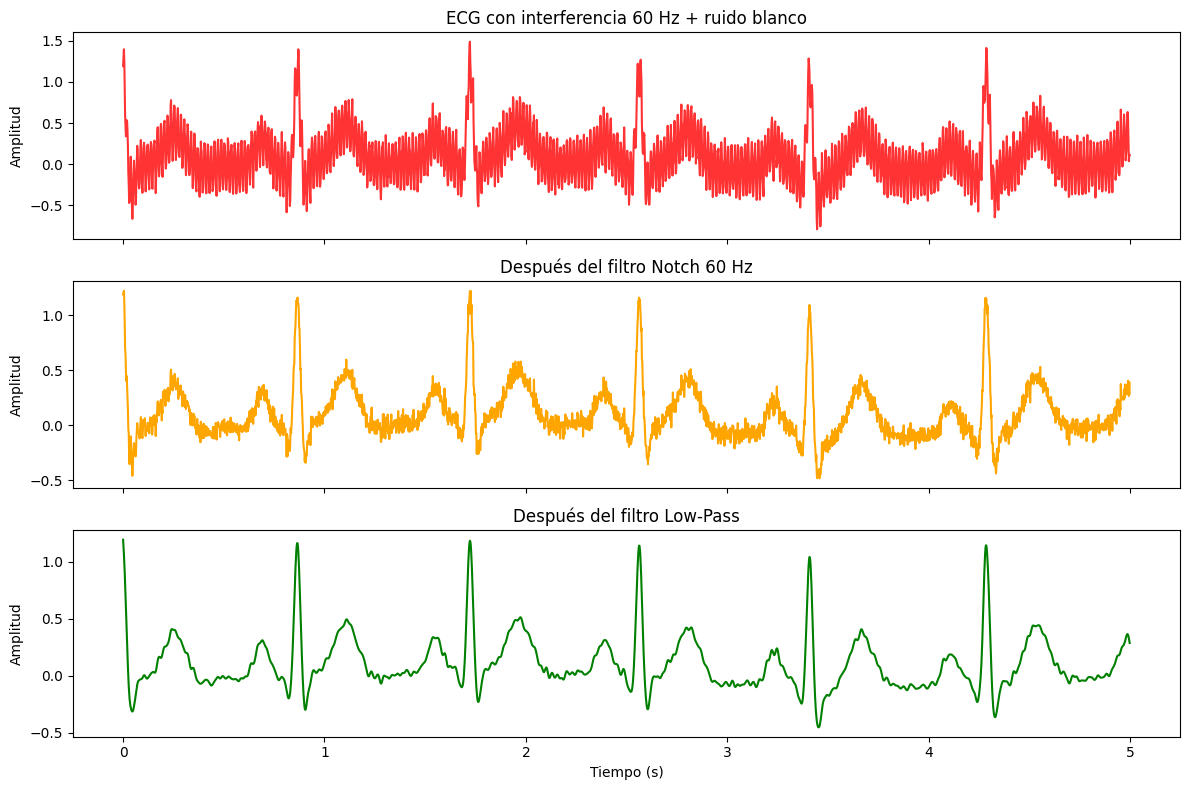

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import neurokit2 as nk
from scipy.signal import iirnotch, butter, filtfilt

fs = 500
duracion = 5
t = np.linspace(0, duracion, fs * duracion, endpoint=False)

# ECG sintético con NeuroKit2
ecg = nk.ecg_simulate(duration=duracion, sampling_rate=fs, heart_rate=70, noise=0.05)

# Añadir ruido 60 Hz (interferencia eléctrica) + ruido blanco
ruido_60hz = 0.3 * np.sin(2 * np.pi * 60 * t)
ruido_blanco = np.random.normal(0, 0.05, len(t))
ecg_ruidoso = ecg + ruido_60hz + ruido_blanco

# PIPELINE DE FILTRADO
# Paso 1: filtro notch para eliminar 60 Hz
b_notch, a_notch = iirnotch(60, Q=30, fs=fs)
ecg_sin60 = filtfilt(b_notch, a_notch, ecg_ruidoso)

# Paso 2: filtro low-pass butterworth para eliminar ruido de alta frecuencia
b_lp, a_lp = butter(4, 40, btype='low', fs=fs)
ecg_filtrado = filtfilt(b_lp, a_lp, ecg_sin60)

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
axes[0].plot(t, ecg_ruidoso, color='red', alpha=0.8)
axes[0].set_title('ECG con interferencia 60 Hz + ruido blanco')
axes[0].set_ylabel('Amplitud')

axes[1].plot(t, ecg_sin60, color='orange')
axes[1].set_title('Después del filtro Notch 60 Hz')
axes[1].set_ylabel('Amplitud')

axes[2].plot(t, ecg_filtrado, color='green')
axes[2].set_title('Después del filtro Low-Pass')
axes[2].set_ylabel('Amplitud')
axes[2].set_xlabel('Tiempo (s)')

plt.tight_layout()
plt.savefig('ejercicio4_interferencia60hz.png', dpi=150)
plt.show()

##Ejercicio 5

Delay estimado ECG:          1.00 s   (real: 1.00 s)
Delay estimado Respiración:  2.00 s   (real: 2.00 s)
Delay estimado Acelerómetro: 0.66 s   (real: 1.50 s)


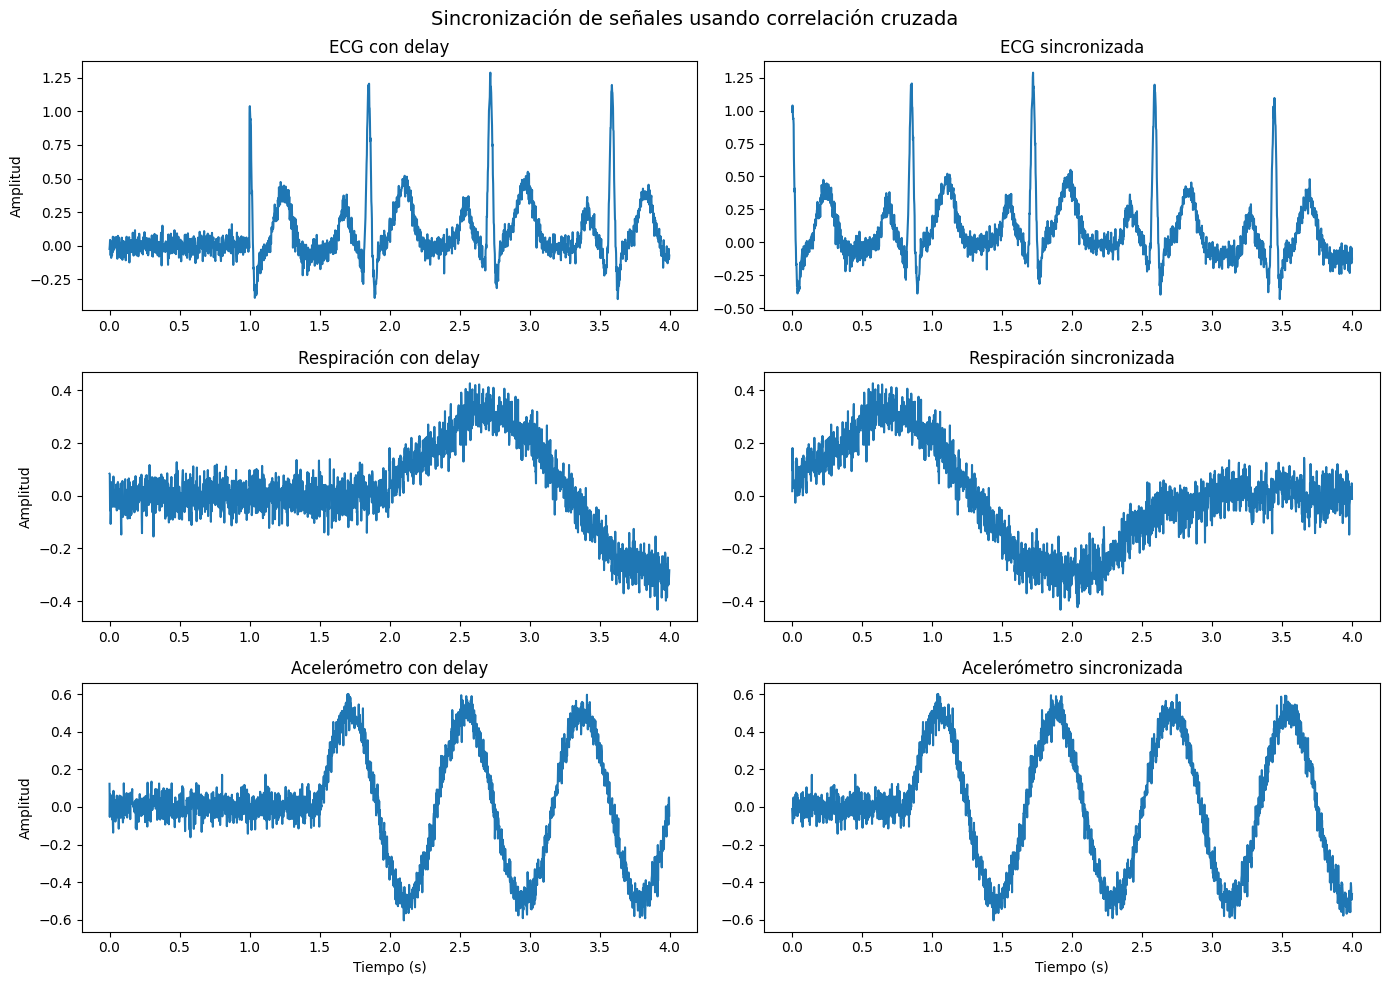

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import neurokit2 as nk
from scipy.signal import correlate

# Parámetros generales
fs = 500
duracion = 10
n = fs * duracion

t = np.linspace(0, duracion, n, endpoint=False)

# ECG sintético
ecg = nk.ecg_simulate(
    duration=duracion,
    sampling_rate=fs,
    heart_rate=70,
    noise=0.02
)[:n]

# Respiración sintética
resp = nk.rsp_simulate(
    duration=duracion,
    sampling_rate=fs,
    respiratory_rate=15,
    noise=0.02
)[:n]

# Acelerómetro sintético
accel = 0.5 * np.sin(2 * np.pi * 1.2 * t)

# Delays distintos (~2 s)
delay_ecg   = int(1.0 * fs)   # 1.0 s
delay_resp  = int(2.0 * fs)   # 2.0 s
delay_accel = int(1.5 * fs)   # 1.5 s

# Función para aplicar delay real (NO circular)
def aplicar_delay(signal, delay):
    delayed = np.zeros_like(signal)
    delayed[delay:] = signal[:-delay]
    return delayed

# Aplicar delay + ruido
ecg_d = aplicar_delay(ecg, delay_ecg) + np.random.normal(0, 0.05, n)

resp_d = aplicar_delay(resp, delay_resp) + np.random.normal(0, 0.05, n)

accel_d = aplicar_delay(accel, delay_accel) + np.random.normal(0, 0.05, n)

def estimar_delay(ref, signal):
    corr = correlate(signal, ref, mode='full')
    lags = np.arange(-len(ref) + 1, len(ref))
    delay = lags[np.argmax(corr)]
    return delay

# Estimar delays
lag_ecg   = estimar_delay(ecg, ecg_d)
lag_resp  = estimar_delay(resp, resp_d)
lag_accel = estimar_delay(accel, accel_d)

# Función para corregir delay
def corregir_delay(signal, delay):
    corrected = np.zeros_like(signal)

    if delay > 0:
        corrected[:-delay] = signal[delay:]
    else:
        corrected = signal.copy()

    return corrected

# Señales sincronizadas
ecg_sync   = corregir_delay(ecg_d, lag_ecg)
resp_sync  = corregir_delay(resp_d, lag_resp)
accel_sync = corregir_delay(accel_d, lag_accel)


print(f"Delay estimado ECG:          {lag_ecg/fs:.2f} s   (real: {delay_ecg/fs:.2f} s)")
print(f"Delay estimado Respiración:  {lag_resp/fs:.2f} s   (real: {delay_resp/fs:.2f} s)")
print(f"Delay estimado Acelerómetro: {lag_accel/fs:.2f} s   (real: {delay_accel/fs:.2f} s)")

fig, axes = plt.subplots(3, 2, figsize=(14, 10))

senales = [
    (ecg_d, ecg_sync, 'ECG'),
    (resp_d, resp_sync, 'Respiración'),
    (accel_d, accel_sync, 'Acelerómetro')
]

for i, (signal_delay, signal_sync, nombre) in enumerate(senales):

    # Señal desincronizada
    axes[i, 0].plot(t[:fs*4], signal_delay[:fs*4])
    axes[i, 0].set_title(f'{nombre} con delay')
    axes[i, 0].set_ylabel('Amplitud')

    # Señal sincronizada
    axes[i, 1].plot(t[:fs*4], signal_sync[:fs*4])
    axes[i, 1].set_title(f'{nombre} sincronizada')

for ax in axes[-1]:
    ax.set_xlabel('Tiempo (s)')

plt.suptitle('Sincronización de señales usando correlación cruzada', fontsize=14)

plt.tight_layout()

plt.savefig('ejercicio5_sensores_desincronizados.png', dpi=150)

plt.show()

##Ejercicio 6

ECG original:        2500 muestras   → resampled: 2500
Respiración original:397 muestras   → resampled: 2500
Acelerómetro original:1000 muestras  → resampled: 2500


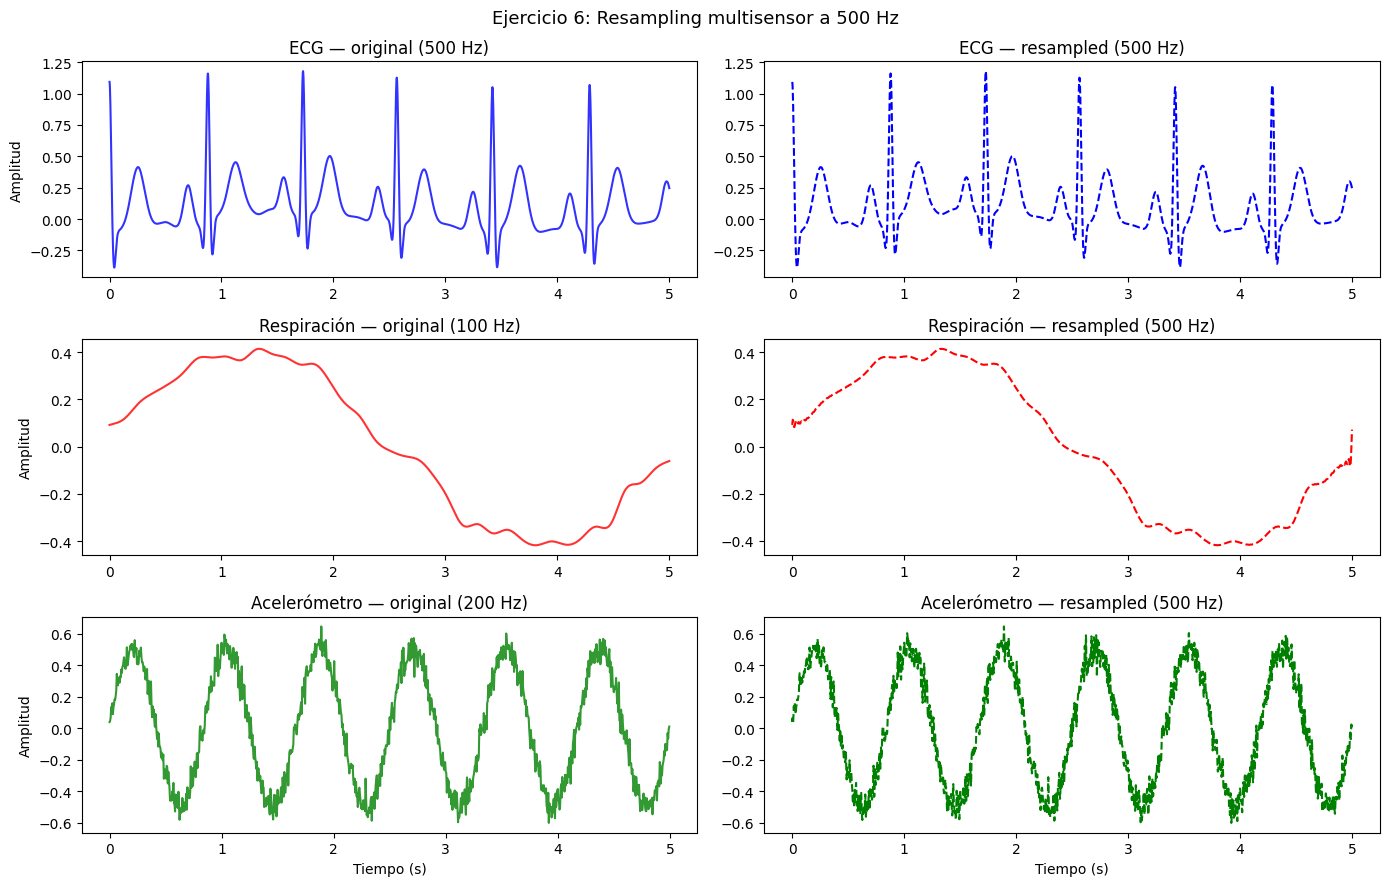

Todas las señales están ahora a 500 Hz y sincronizadas temporalmente.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import neurokit2 as nk
from scipy.signal import resample

# Frecuencias de muestreo originales
fs_ecg   = 500
fs_resp  = 100
fs_accel = 200
fs_target = 500   # frecuencia objetivo
duracion = 5

# Generar señales a sus frecuencias originales
ecg   = nk.ecg_simulate(duration=duracion, sampling_rate=fs_ecg,   heart_rate=70,  noise=0.05)
resp  = nk.rsp_simulate(duration=duracion, sampling_rate=fs_resp,  respiratory_rate=15, noise=0.05)
t_accel = np.linspace(0, duracion, fs_accel * duracion, endpoint=False)
accel = 0.5 * np.sin(2 * np.pi * 1.2 * t_accel) + np.random.normal(0, 0.05, len(t_accel))

n_target = fs_target * duracion   # número de muestras objetivo

# RESAMPLING a 500 Hz
ecg_rs   = ecg                          # ya está a 500 Hz
resp_rs  = resample(resp,  n_target)
accel_rs = resample(accel, n_target)

t = np.linspace(0, duracion, n_target)

print(f"ECG original:        {len(ecg)} muestras   → resampled: {len(ecg_rs)}")
print(f"Respiración original:{len(resp)} muestras   → resampled: {len(resp_rs)}")
print(f"Acelerómetro original:{len(accel)} muestras  → resampled: {len(accel_rs)}")

# Visualización comparativa
fig, axes = plt.subplots(3, 2, figsize=(14, 9))

pares = [
    (np.linspace(0, duracion, len(ecg)),   ecg,   ecg_rs,   'ECG',          'blue'),
    (np.linspace(0, duracion, len(resp)),  resp,  resp_rs,  'Respiración',  'red'),
    (t_accel,                              accel, accel_rs, 'Acelerómetro', 'green'),
]

for i, (t_orig, orig, rs, nombre, color) in enumerate(pares):
    axes[i, 0].plot(t_orig, orig, color=color, alpha=0.8)
    axes[i, 0].set_title(f'{nombre} — original ({[fs_ecg,fs_resp,fs_accel][i]} Hz)')
    axes[i, 0].set_ylabel('Amplitud')

    axes[i, 1].plot(t, rs, color=color, linestyle='--')
    axes[i, 1].set_title(f'{nombre} — resampled ({fs_target} Hz)')

for ax in axes[-1]:
    ax.set_xlabel('Tiempo (s)')

plt.suptitle('Ejercicio 6: Resampling multisensor a 500 Hz', fontsize=13)
plt.tight_layout()
plt.savefig('ejercicio6_resampling.png', dpi=150)
plt.show()
print("Todas las señales están ahora a 500 Hz y sincronizadas temporalmente.")